# Week 1 캐스팅 이미지 프롬프트 실험

- 시스템 프롬프트: `aidol-casting-system-prompt.md` (바이럴 프롬프트 기반)
- 샘플 데이터: `casting-sample-data.json` (04-ai-idol-guide.md A/B/C/D TYPE 기반)
- 모델: `gemini-3.1-flash-image-preview` (Nano Banana 2)

## 0. 환경 설정

In [69]:
import subprocess, sys
for pkg in ["google-genai", "Pillow", "pandas"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

In [70]:
import os
import json
import time
import base64
import html as _html
from pathlib import Path
from datetime import datetime
from io import BytesIO

import pandas as pd
from PIL import Image
from google import genai
from google.genai import types
from IPython.display import display, HTML, Image as IPImage

In [71]:
os.chdir('/home/chlee/Projects/aidol-docs/05_ai-llm')

In [72]:
API_KEY = os.environ.get("GOOGLE_API_KEY")
client = genai.Client(api_key=API_KEY)
MODEL_ID = "gemini-3.1-flash-image-preview"
OUTPUT_DIR = Path("/home/chlee/Projects/aidol-docs/05_ai-llm/experiments/week1-v3-images-nomakeup")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Model: {MODEL_ID}")
print(f"Output: {OUTPUT_DIR}")

Model: gemini-3.1-flash-image-preview
Output: /home/chlee/Projects/aidol-docs/05_ai-llm/experiments/week1-v3-images-nomakeup


## 1. 샘플 데이터 & 시스템 프롬프트 로드

In [73]:
# ── (1) 고정 블록: casting_image_prompt.py에서 import ──
import importlib.util
spec = importlib.util.spec_from_file_location(
    "casting_image_prompt", "prompts/casting_image_prompt.py"
)
casting_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(casting_mod)

SYSTEM_PROMPT_FIXED = casting_mod.CASTING_SYSTEM_PROMPT  # 고정 블록 전문
BLOCK_FOLLOW_REF = casting_mod.BLOCK_FOLLOW_REF          # 블록② (Week 2+에서 활성화)

# ── (2) 가변 블록 매핑 테이블 ──
with open("prompts/casting_variable_blocks.json", "r", encoding="utf-8") as f:
    vb_data = json.load(f)
VARIABLE_BLOCKS = vb_data["variable_blocks"]

# ── (3) 실험용 조합 샘플 ──
with open("casting_combinations_sample.json", "r", encoding="utf-8") as f:
    combo_data = json.load(f)
COMBINATIONS = combo_data["combinations"]

print(f"고정 블록 길이: {len(SYSTEM_PROMPT_FIXED)} chars")
print(f"가변 블록 카테고리: {list(VARIABLE_BLOCKS.keys())}")
print(f"조합 수: {len(COMBINATIONS)}")

고정 블록 길이: 513 chars
가변 블록 카테고리: ['ethnicity', 'gender', 'mood', 'impression', 'hairstyle']
조합 수: 17


In [74]:
def build_prompt(combo: dict) -> str:
    """가변 블록 조합으로부터 최종 프롬프트를 조립합니다.
    
    구조: 블록③ 가변(User Selection) + 블록④ 고정(Quality)
    """
    
    # 가변 블록 매핑 (한국어 UI 값 → 영어 프롬프트 값)
    ethnicity_en = VARIABLE_BLOCKS["ethnicity"][combo["ethnicity"]]
    gender_en = VARIABLE_BLOCKS["gender"][combo["gender"]]
    mood_en = VARIABLE_BLOCKS["mood"][combo["mood"]]
    impression_en = VARIABLE_BLOCKS["impression"][combo["impression"]]
    hairstyle_en = VARIABLE_BLOCKS["hairstyle"][combo["hairstyle"]]
    
    # 블록 ③ User Selection (가변)
    block_3 = f"{ethnicity_en} {gender_en}, {mood_en}, {impression_en}, {hairstyle_en}."
    
    # 블록 ④ Quality (고정) — [수정] 기존 SYSTEM_PROMPT["block_4_quality"] → SYSTEM_PROMPT_FIXED
    block_4 = SYSTEM_PROMPT_FIXED
    
    # 최종 조립: 블록③ + 블록④
    prompt = f"{block_3}\n\n{block_4}"
    
    return prompt


# 테스트: 첫 번째 조합의 프롬프트 확인
test_prompt = build_prompt(COMBINATIONS[0])
print("=== 조합 A1 프롬프트 ===\n")
print(test_prompt)


=== 조합 A1 프롬프트 ===

East Asian Male, chic and charismatic, sharp features, intense gaze, sculpted jawline, black short textured hair.

Photorealistic K-pop trainee profile photo.
Captivating idol face with refined features.
Smooth radiant skin, natural texture, age 18.

Very tight chest-up portrait, head 58% of frame height, centered.
Front-facing, eyes at camera.
White crew-neck t-shirt.

#9BB3C4 muted blue-gray studio backdrop.
Single solid color only, no gradient, no objects, no walls, no windows, no environment.

Soft studio lighting, pure white light.
Symmetrical even illumination, soft shadow under chin only.

85mm f/1.8, sharp focus.


## 2. 이미지 생성 함수

In [75]:
# COST_PER_IMAGE_1K = 0.067
COST_PER_IMAGE_05K = 0.045

def generate_image(prompt: str, filename: str) -> dict:
    """Gemini API로 이미지 생성. Week 1은 reference image 없이 텍스트만."""
    start = time.time()
    result = {
        "filename": filename,
        "prompt": prompt,
        "elapsed": 0,
        "error": None,
        "image_path": None,
        "image_size": None,
        "cost": 0,
    }

    try:
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=[prompt],
            config=types.GenerateContentConfig(
                response_modalities=["IMAGE", "TEXT"],
                image_config=types.ImageConfig(
                    image_size="512",
                    aspect_ratio="9:16",
                ),
            ),
        )

        img_saved = False
        for part in response.candidates[0].content.parts:
            if part.inline_data and part.inline_data.mime_type.startswith("image/"):
                img = Image.open(BytesIO(part.inline_data.data))
                save_path = OUTPUT_DIR / filename
                img.save(save_path)
                result["image_path"] = str(save_path)
                result["image_size"] = img.size
                result["cost"] = COST_PER_IMAGE_05K  # 512x512 이미지 기준
                img_saved = True
                
                # 노트북에서 미리보기
                thumb = img.copy()
                thumb.thumbnail((250, 310))
                display(thumb)
                break

        if not img_saved:
            result["error"] = "응답에 이미지 없음"

    except Exception as e:
        result["error"] = str(e)

    result["elapsed"] = round(time.time() - start, 2)
    return result

## 3. 전체 조합 실험 실행


조합 A1: BOY A — 시크 / 날카로운 / 블랙 숏컷


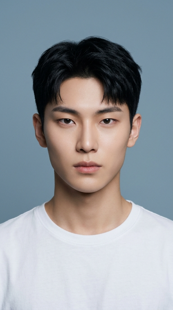

  [trial 1] 10.37s - OK


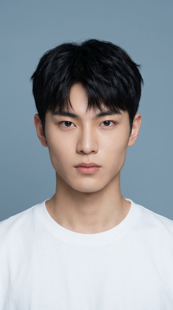

  [trial 2] 10.93s - OK

조합 A2: BOY A — 청량 / 세련된 / 브라운 미디엄


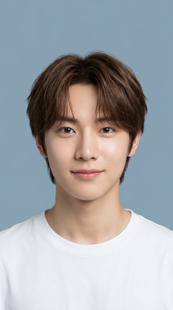

  [trial 1] 10.57s - OK


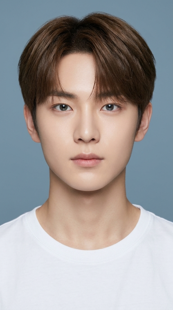

  [trial 2] 8.95s - OK

조합 A3: BOY A — 시크 / 날카로운 / 애쉬그레이


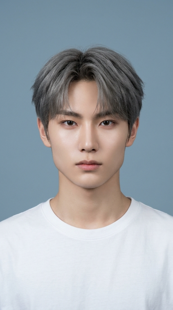

  [trial 1] 9.75s - OK


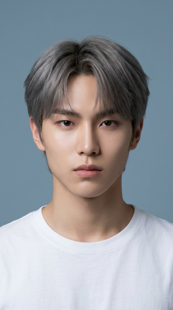

  [trial 2] 9.27s - OK

조합 B1: BOY B — 청량 / 부드러운 / 블랙 롱


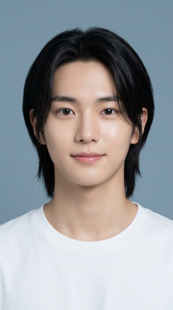

  [trial 1] 9.73s - OK


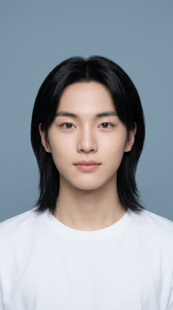

  [trial 2] 9.67s - OK

조합 B2: BOY B — 청량 / 세련된 / 다크브라운 웨이브


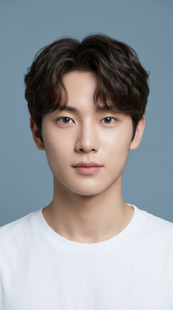

  [trial 1] 9.53s - OK


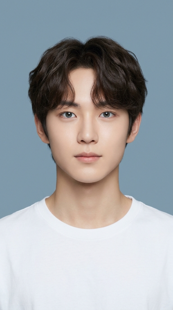

  [trial 2] 9.76s - OK

조합 C1: BOY C — 중성적 / 요정 / 블랙 머쉬룸


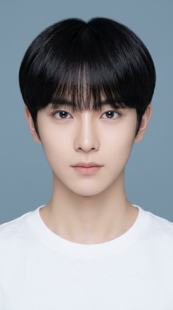

  [trial 1] 9.81s - OK


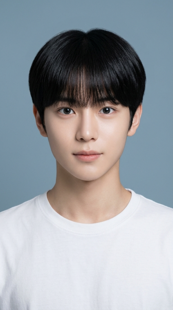

  [trial 2] 9.81s - OK

조합 C2: BOY C — 중성적 / 동글동글 / 브라운 미디엄


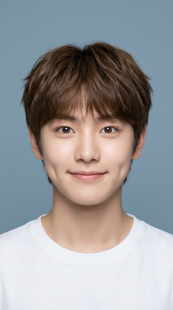

  [trial 1] 10.0s - OK


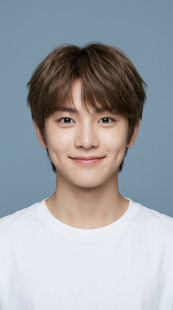

  [trial 2] 9.85s - OK

조합 D1: BOY D — 청량 / 부드러운 / 다크브라운 웨이브


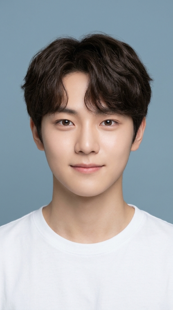

  [trial 1] 11.14s - OK


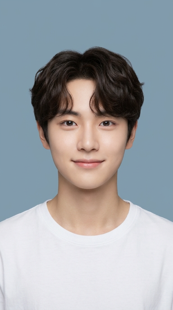

  [trial 2] 8.87s - OK

조합 G1: GIRL — 걸크러시 / 강한 눈매 / 블론드 롱


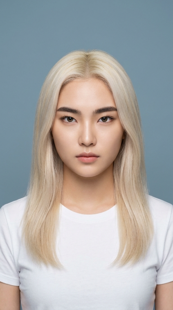

  [trial 1] 9.82s - OK


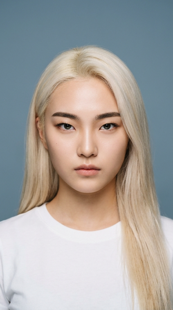

  [trial 2] 9.67s - OK

조합 G2: GIRL — 청순 / 부드러운 / 블랙 롱


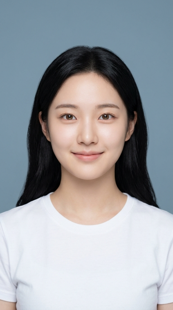

  [trial 1] 9.56s - OK


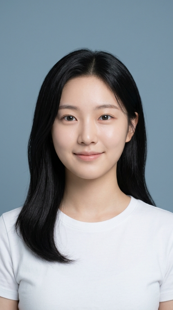

  [trial 2] 9.37s - OK

조합 G3: GIRL — 큐트 / 동글동글 / 핑크 밥컷


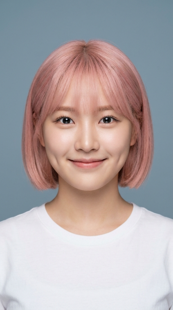

  [trial 1] 10.14s - OK


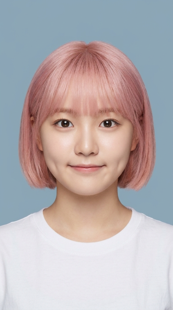

  [trial 2] 8.87s - OK

조합 G4: GIRL — 시크 / 날카로운 / 블랙 롱


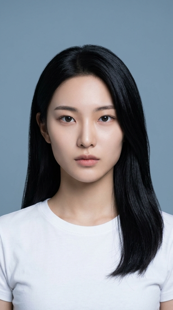

  [trial 1] 8.86s - OK


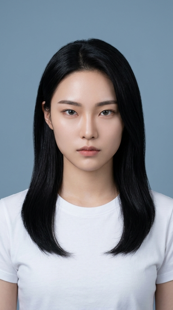

  [trial 2] 10.52s - OK

조합 G5: GIRL — 청량 / 세련된 / 블랙 하이포니


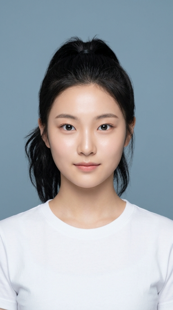

  [trial 1] 10.56s - OK


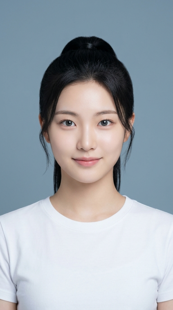

  [trial 2] 9.94s - OK

조합 MIX1: BOY MIX — 다크 / 묵직한 / 실버 숏컷 (혼혈)


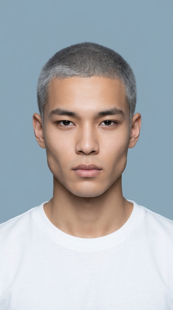

  [trial 1] 9.75s - OK


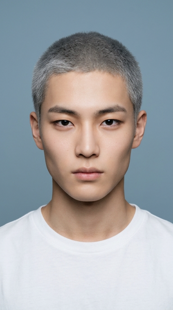

  [trial 2] 10.45s - OK

조합 MIX2: GIRL MIX — 걸크러시 / 강한 눈매 / 블랙 롱 (동남아)


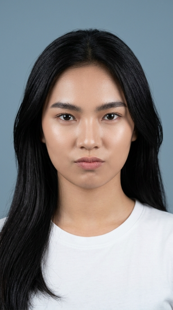

  [trial 1] 8.93s - OK


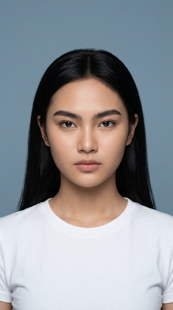

  [trial 2] 9.86s - OK

조합 MIX3: BOY MIX — 청량 / 세련된 / 브라운 미디엄 (유럽)


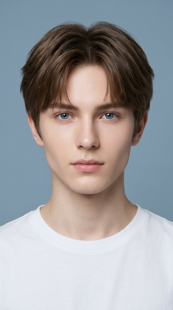

  [trial 1] 10.34s - OK


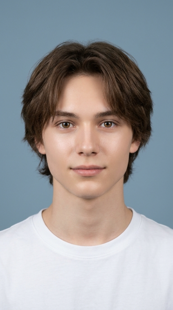

  [trial 2] 11.43s - OK

조합 MIX4: BOY MIX — 시크 / 날카로운 / 블랙 숏컷 (남미)


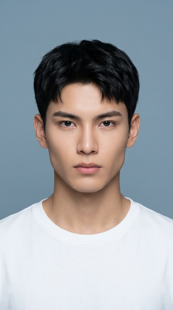

  [trial 1] 9.47s - OK


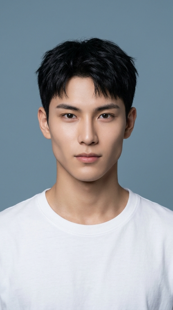

  [trial 2] 11.96s - OK

=== 실험 완료: 34장 생성 ===
성공: 34 | 에러: 0
총 비용: $1.53


In [76]:
# ── 3.1 전체 조합 실험 ──
# 각 조합마다 2장씩 생성 (동일 프롬프트, 시드 변경 효과)

TRIALS_PER_COMBO = 2
all_results = []

for combo in COMBINATIONS:
    combo_id = combo["id"]
    combo_name = combo["name"]
    prompt = build_prompt(combo)
    
    print(f"\n{'='*60}")
    print(f"조합 {combo_id}: {combo_name}")
    print(f"{'='*60}")
    
    for trial in range(1, TRIALS_PER_COMBO + 1):
        filename = f"w1v3_{combo_id}_trial{trial}.png"
        result = generate_image(prompt, filename)
        result["combo_id"] = combo_id
        result["combo_name"] = combo_name
        result["trial"] = trial
        result["note"] = combo.get("note", "")
        all_results.append(result)
        
        status = "OK" if result["error"] is None else f"ERR: {result['error']}"
        print(f"  [trial {trial}] {result['elapsed']}s - {status}")
        
        time.sleep(2)  # API rate limit 방지

all_df = pd.DataFrame(all_results)
print(f"\n=== 실험 완료: {len(all_df)}장 생성 ===")
print(f"성공: {len(all_df[all_df['error'].isna()])} | 에러: {len(all_df[all_df['error'].notna()])}")
print(f"총 비용: ${all_df['cost'].sum():.2f}")

## 4. HTML 리포트 생성

In [77]:
# ── 4.1 이미지 base64 인코딩 유틸 ──

def img_to_base64(path: str, max_width: int = 400) -> str:
    if not path or not Path(path).exists():
        return ""
    img = Image.open(path)
    if img.width > max_width:
        ratio = max_width / img.width
        img = img.resize((max_width, int(img.height * ratio)))
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    return f"data:image/png;base64,{b64}"

In [78]:
# ── 4.2 HTML 리포트 생성 ──
# [수정] background color: 다크 → 아이보리
# [수정] 텍스트 색상: 밝은 회색 → 다크 계열로 변경

def generate_report(df: pd.DataFrame, combinations: list, filename: str):
    now = datetime.now().strftime("%Y-%m-%d %H:%M")
    total_ok = len(df[df["error"].isna()])
    total_err = len(df[df["error"].notna()])
    total_cost = df["cost"].sum()
    avg_time = df["elapsed"].mean()

    # [수정] 아이보리 배경 (#FFFFF0 계열)
    html = f"""<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<title>Week 1 캐스팅 이미지 프롬프트 실험 (v3)</title>
<style>
    * {{ margin: 0; padding: 0; box-sizing: border-box; }}
    body {{ font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
           background: #FFFFF5; min-height: 100vh; padding: 24px; color: #333; }}
    .container {{ max-width: 1200px; margin: 0 auto; }}
    h1 {{ text-align: center; font-size: 1.8em; margin-bottom: 6px; color: #2c2c2c; }}
    h2 {{ color: #5a4a3a; border-bottom: 2px solid #d4c5a9; padding-bottom: 8px;
         margin: 30px 0 16px; font-size: 1.3em; }}
    .subtitle {{ text-align: center; color: #888; margin-bottom: 24px; font-size: 0.9em; }}

    .summary {{ display: flex; gap: 14px; justify-content: center; flex-wrap: wrap; margin-bottom: 30px; }}
    .summary-card {{ background: #faf8f0; border: 1px solid #d4c5a9; border-radius: 12px;
                    padding: 16px 22px; text-align: center; min-width: 130px; }}
    .summary-card .value {{ font-size: 1.5em; font-weight: 700; color: #8b6914; }}
    .summary-card .label {{ font-size: 0.82em; color: #999; margin-top: 4px; }}

    table {{ width: 100%; border-collapse: collapse; background: #faf8f0;
           border-radius: 10px; overflow: hidden; margin-bottom: 20px; }}
    th {{ background: #f0ead6; color: #5a4a3a; padding: 10px 12px;
        text-align: left; font-size: 0.88em; }}
    td {{ padding: 8px 12px; border-top: 1px solid #e8e0d0; font-size: 0.86em; }}
    tr:hover {{ background: #f5f0e0; }}

    .combo-section {{ margin-bottom: 32px; }}
    .combo-header {{ background: #f0ead6; border: 1px solid #d4c5a9;
                    border-radius: 12px 12px 0 0; padding: 14px 18px; }}
    .combo-header h3 {{ color: #5a4a3a; font-size: 1.1em; }}
    .combo-prompt {{ background: #faf8f0; padding: 10px 14px;
                    border-radius: 0 0 12px 12px; border: 1px solid #d4c5a9;
                    border-top: none; font-size: 0.82em; color: #777;
                    font-family: monospace; white-space: pre-wrap; word-break: break-all; }}

    .img-grid {{ display: grid; grid-template-columns: repeat(auto-fill, minmax(220px, 1fr));
               gap: 14px; margin: 16px 0; }}
    .img-card {{ background: #faf8f0; border: 1px solid #d4c5a9;
               border-radius: 10px; overflow: hidden; }}
    .img-card img {{ width: 100%; display: block; }}
    .img-card .meta {{ padding: 8px 10px; font-size: 0.8em; color: #999; }}
</style>
</head>
<body>
<div class="container">
    <h1>Week 1 캐스팅 이미지 프롬프트 실험 (v3)</h1>
    <p class="subtitle">모델: {MODEL_ID} | 생성일: {now} | 시스템 프롬프트: aidol-casting-system-prompt.md</p>

    <div class="summary">
        <div class="summary-card"><div class="value">{total_ok}</div><div class="label">성공</div></div>
        <div class="summary-card"><div class="value">{total_err}</div><div class="label">에러</div></div>
        <div class="summary-card"><div class="value">${total_cost:.2f}</div><div class="label">총 비용</div></div>
        <div class="summary-card"><div class="value">{avg_time:.1f}s</div><div class="label">평균 시간</div></div>
        <div class="summary-card"><div class="value">{len(combinations)}</div><div class="label">조합 수</div></div>
    </div>
"""

    # ── 조합별 결과 ──
    html += "    <h2>조합별 결과</h2>\n"

    for combo in combinations:
        combo_id = combo["id"]
        combo_data = df[df["combo_id"] == combo_id]
        prompt_text = build_prompt(combo)

        html += f"""
    <div class="combo-section">
        <div class="combo-header">
            <h3>{combo_id}: {combo['name']}</h3>
            <div style="font-size:0.8em;color:#999;margin-top:4px;">{combo.get('note','')}</div>
            <div style="font-size:0.8em;color:#5a4a3a;margin-top:6px;">
                인종: {combo['ethnicity']} → {VARIABLE_BLOCKS['ethnicity'][combo['ethnicity']]} |
                성별: {combo['gender']} → {VARIABLE_BLOCKS['gender'][combo['gender']]} |
                분위기: {combo['mood']} → {VARIABLE_BLOCKS['mood'][combo['mood']]} |
                인상: {combo['impression']} → {VARIABLE_BLOCKS['impression'][combo['impression']]} |
                헤어: {combo['hairstyle']} → {VARIABLE_BLOCKS['hairstyle'][combo['hairstyle']]}
            </div>
        </div>
        <div class="combo-prompt">{_html.escape(prompt_text)}</div>
        <div class="img-grid">
"""
        for _, row in combo_data.iterrows():
            if row["error"] is None and row["image_path"]:
                b64 = img_to_base64(row["image_path"])
                html += f"""            <div class="img-card">
                <img src="{b64}" alt="{combo_id}">
                <div class="meta">trial {row['trial']} | {row['elapsed']}s | ${row['cost']:.3f} | {row['image_size']}</div>
            </div>
"""
            else:
                html += f"""            <div class="img-card">
                <div style="padding:40px;text-align:center;color:#c00;">에러: {row.get('error','')}</div>
            </div>
"""
        html += "        </div>\n    </div>\n"

#     # ── 네거티브 프롬프트 표시 ──
#     html += f"""
#     <h2>네거티브 프롬프트 (공통)</h2>
#     <div class="combo-prompt">{_html.escape(NEGATIVE_PROMPT)}</div>
# """

    # ── 풋터 ──
    html += f"""
    <div style="margin-top:40px;padding-top:16px;border-top:1px solid #d4c5a9;color:#999;
               font-size:0.8em;text-align:center;">
        Week 1 v3 캐스팅 이미지 프롬프트 실험 | 모델: {MODEL_ID} | {now}
    </div>
</div>
</body>
</html>"""

    report_path = Path(filename)
    report_path.parent.mkdir(parents=True, exist_ok=True)
    report_path.write_text(html, encoding="utf-8")
    print(f"HTML 리포트 저장: {report_path}")
    print(f"파일 크기: {report_path.stat().st_size / 1024:.0f} KB")
    return str(report_path)

In [79]:
# ── 4.3 리포트 생성 ──

report_path = generate_report(
    all_df,
    COMBINATIONS,
    filename="experiments/casting-experiment-v3-report-nomakeup.html",
)

display(HTML(f'<a href="{report_path}" target="_blank">리포트 열기</a>'))

HTML 리포트 저장: experiments/casting-experiment-v3-report-nomakeup.html
파일 크기: 15055 KB
